In [1]:
import pandas as pd 

In [2]:
data = pd.read_csv("heart.csv")

In [3]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
#data #93, 159, 164, 165 and 252 have ca=4 which is incorrect. In the original Cleveland dataset they are NaNs.
# data #49 and 282 have thal = 0, also incorrect. They are also NaNs in the original dataset.
# Action: Drop the faulty data! (7 data entry will be dropped)
faulty_rows = [48, 92, 158, 163, 164, 251, 281]
data = data.drop(faulty_rows)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       296 non-null    int64  
 1   sex       296 non-null    int64  
 2   cp        296 non-null    int64  
 3   trestbps  296 non-null    int64  
 4   chol      296 non-null    int64  
 5   fbs       296 non-null    int64  
 6   restecg   296 non-null    int64  
 7   thalach   296 non-null    int64  
 8   exang     296 non-null    int64  
 9   oldpeak   296 non-null    float64
 10  slope     296 non-null    int64  
 11  ca        296 non-null    int64  
 12  thal      296 non-null    int64  
 13  target    296 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 34.7 KB


In [7]:
data = data.rename(
    columns = {'cp':'chest_pain_type', 
               'trestbps':'resting_blood_pressure', 
               'chol': 'cholesterol',
               'fbs': 'fasting_blood_sugar',
               'restecg' : 'resting_electrocardiogram', 
               'thalach': 'max_heart_rate_achieved', 
               'exang': 'exercise_induced_angina',
               'oldpeak': 'st_depression', 
               'slope': 'st_slope', 
               'ca':'num_major_vessels', 
               'thal': 'thalassemia'}, 
    errors="raise")

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        296 non-null    int64  
 1   sex                        296 non-null    int64  
 2   chest_pain_type            296 non-null    int64  
 3   resting_blood_pressure     296 non-null    int64  
 4   cholesterol                296 non-null    int64  
 5   fasting_blood_sugar        296 non-null    int64  
 6   resting_electrocardiogram  296 non-null    int64  
 7   max_heart_rate_achieved    296 non-null    int64  
 8   exercise_induced_angina    296 non-null    int64  
 9   st_depression              296 non-null    float64
 10  st_slope                   296 non-null    int64  
 11  num_major_vessels          296 non-null    int64  
 12  thalassemia                296 non-null    int64  
 13  target                     296 non-null    int64  
dtyp

In [9]:
#We replacing the coded categories(0,1,2..) to their meaning ('atypical angina', 'typical angina', etc. for example)
data['sex'][data['sex'] == 0] = 'female'
data['sex'][data['sex'] == 1] = 'male'

data['chest_pain_type'][data['chest_pain_type'] == 0] = 'typical angina'
data['chest_pain_type'][data['chest_pain_type'] == 1] = 'atypical angina'
data['chest_pain_type'][data['chest_pain_type'] == 2] = 'non-anginal pain'
data['chest_pain_type'][data['chest_pain_type'] == 3] = 'asymptomatic'

data['fasting_blood_sugar'][data['fasting_blood_sugar'] == 0] = 'lower than 120mg/ml'
data['fasting_blood_sugar'][data['fasting_blood_sugar'] == 1] = 'greater than 120mg/ml'

data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 0] = 'normal'
data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 1] = 'ST-T wave abnormality'
data['resting_electrocardiogram'][data['resting_electrocardiogram'] == 2] = 'left ventricular hypertrophy'

data['exercise_induced_angina'][data['exercise_induced_angina'] == 0] = 'no'
data['exercise_induced_angina'][data['exercise_induced_angina'] == 1] = 'yes'

data['st_slope'][data['st_slope'] == 0] = 'upsloping'
data['st_slope'][data['st_slope'] == 1] = 'flat'
data['st_slope'][data['st_slope'] == 2] = 'downsloping'

data['thalassemia'][data['thalassemia'] == 1] = 'fixed defect'
data['thalassemia'][data['thalassemia'] == 2] = 'normal'
data['thalassemia'][data['thalassemia'] == 3] = 'reversable defect'

C:\Users\praya\AppData\Local\Temp\ipykernel_11304\151627395.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['sex'][data['sex'] == 0] = 'female'
C:\Users\praya\AppData\Local\Temp\ipykernel_11304\151627395.py:2: SettingWithCopyWarning

In [10]:
data.dtypes

age                            int64
sex                           object
chest_pain_type               object
resting_blood_pressure         int64
cholesterol                    int64
fasting_blood_sugar           object
resting_electrocardiogram     object
max_heart_rate_achieved        int64
exercise_induced_angina       object
st_depression                float64
st_slope                      object
num_major_vessels              int64
thalassemia                   object
target                         int64
dtype: object

In [11]:
data.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_electrocardiogram,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,male,asymptomatic,145,233,greater than 120mg/ml,normal,150,no,2.3,upsloping,0,fixed defect,1
1,37,male,non-anginal pain,130,250,lower than 120mg/ml,ST-T wave abnormality,187,no,3.5,upsloping,0,normal,1
2,41,female,atypical angina,130,204,lower than 120mg/ml,normal,172,no,1.4,downsloping,0,normal,1
3,56,male,atypical angina,120,236,lower than 120mg/ml,ST-T wave abnormality,178,no,0.8,downsloping,0,normal,1
4,57,female,typical angina,120,354,lower than 120mg/ml,ST-T wave abnormality,163,yes,0.6,downsloping,0,normal,1


In [12]:
#As we have seen above there are three datatypes i.e object, int and floats. Let's group them according to type.
# numerical fearures 6
num_feats = ['age', 'cholesterol', 'resting_blood_pressure', 'max_heart_rate_achieved', 'st_depression', 'num_major_vessels']
# categorical (binary)
bin_feats = ['sex', 'fasting_blood_sugar', 'exercise_induced_angina', 'target']
# caterorical (multi-)
nom_feats= ['chest_pain_type', 'resting_electrocardiogram', 'st_slope', 'thalassemia']
cat_feats = nom_feats + bin_feats

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [14]:
#Exploratory Data Analysis
print(data.shape)

(296, 14)


In [15]:
data.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'resting_electrocardiogram',
       'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression',
       'st_slope', 'num_major_vessels', 'thalassemia', 'target'],
      dtype='object')

In [16]:
data.describe()

,age,resting_blood_pressure,cholesterol,max_heart_rate_achieved,st_depression,num_major_vessels,target
count,296.000000,296.00000,296.000000,296.000000,296.000000,296.000000,296.000000
mean,54.523649,131.60473,247.155405,149.560811,1.059122,0.679054,0.540541
std,9.059471,17.72662,51.977011,22.970792,1.166474,0.939726,0.499198
min,29.000000,94.00000,126.000000,71.000000,0.000000,0.000000,0.000000
25%,48.000000,120.00000,211.000000,133.000000,0.000000,0.000000,0.000000
50%,56.000000,130.00000,242.500000,152.500000,0.800000,0.000000,1.000000
75%,61.000000,140.00000,275.250000,166.000000,1.650000,1.000000,1.000000
max,77.000000,200.00000,564.000000,202.000000,6.200000,3.000000,1.000000


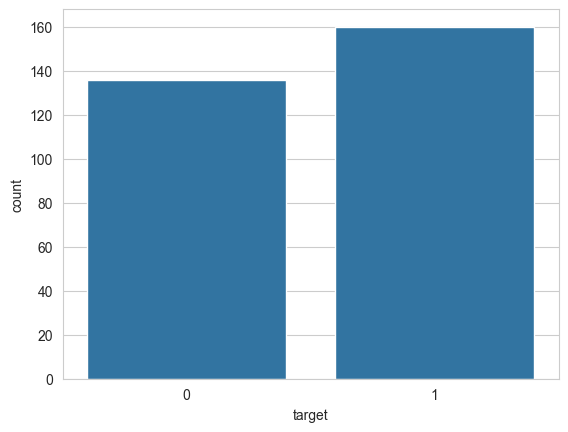

In [17]:
sns.countplot(x='target',data=data)
plt.show()

In [18]:
data['target'].value_counts()

target
1    160
0    136
Name: count, dtype: int64

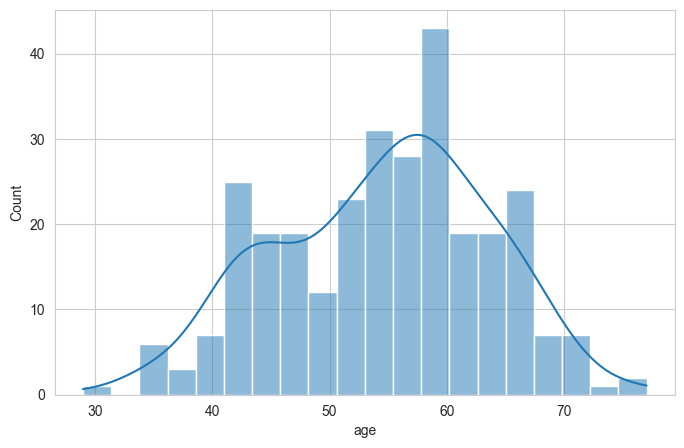

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(data['age'],bins=20,kde=True)
plt.show()

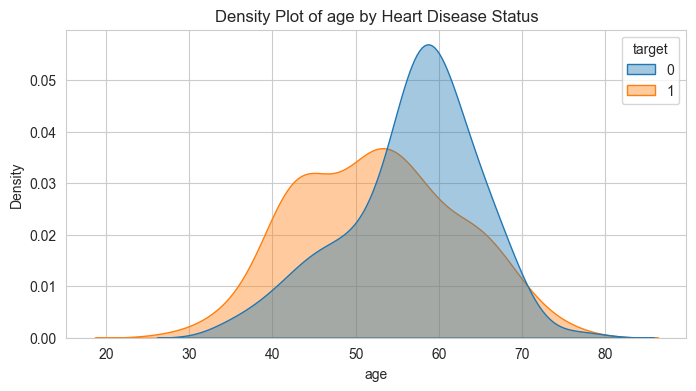

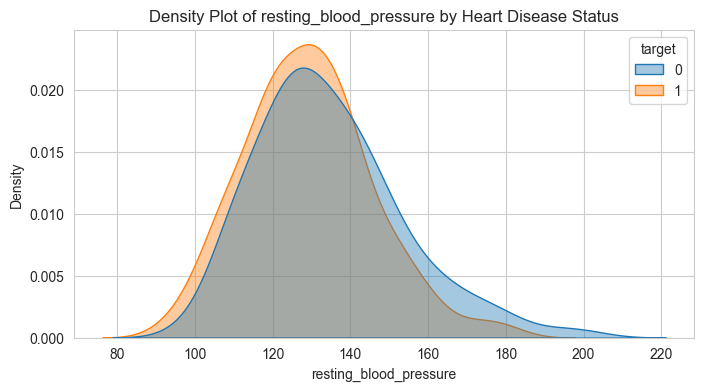

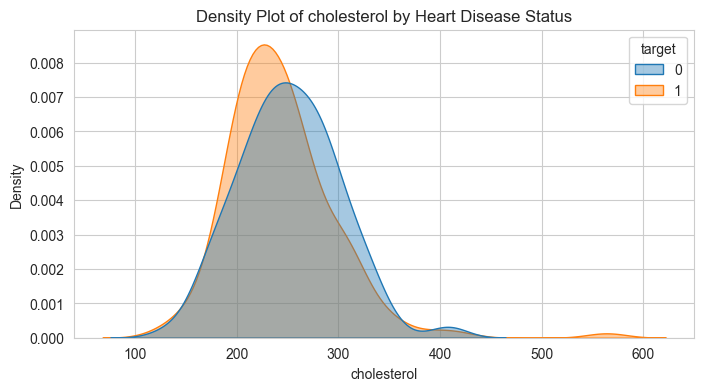

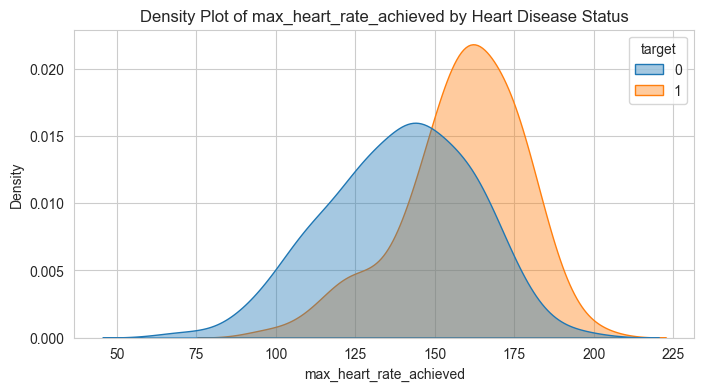

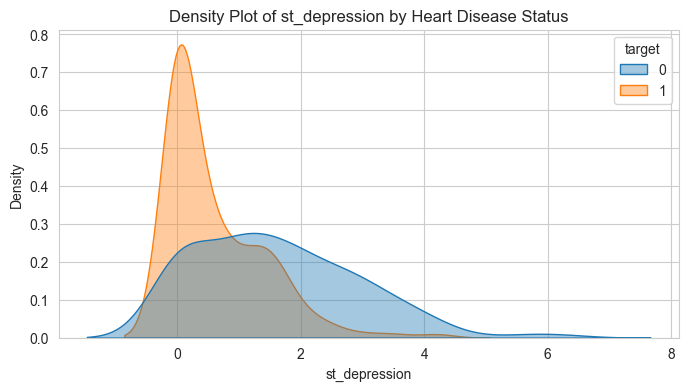

In [20]:

#Distribution: Density plots of Numerical features Vs target
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = [
    'age',
    'resting_blood_pressure',
    'cholesterol',
    'max_heart_rate_achieved',
    'st_depression'
]

for feature in numerical_features:
    plt.figure(figsize=(8, 4))

    sns.kdeplot(
        data=data,
        x=feature,
        hue='target',
        fill=True,
        common_norm=False,
        alpha=0.4
    )

    plt.title(f'Density Plot of {feature} by Heart Disease Status')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.show()


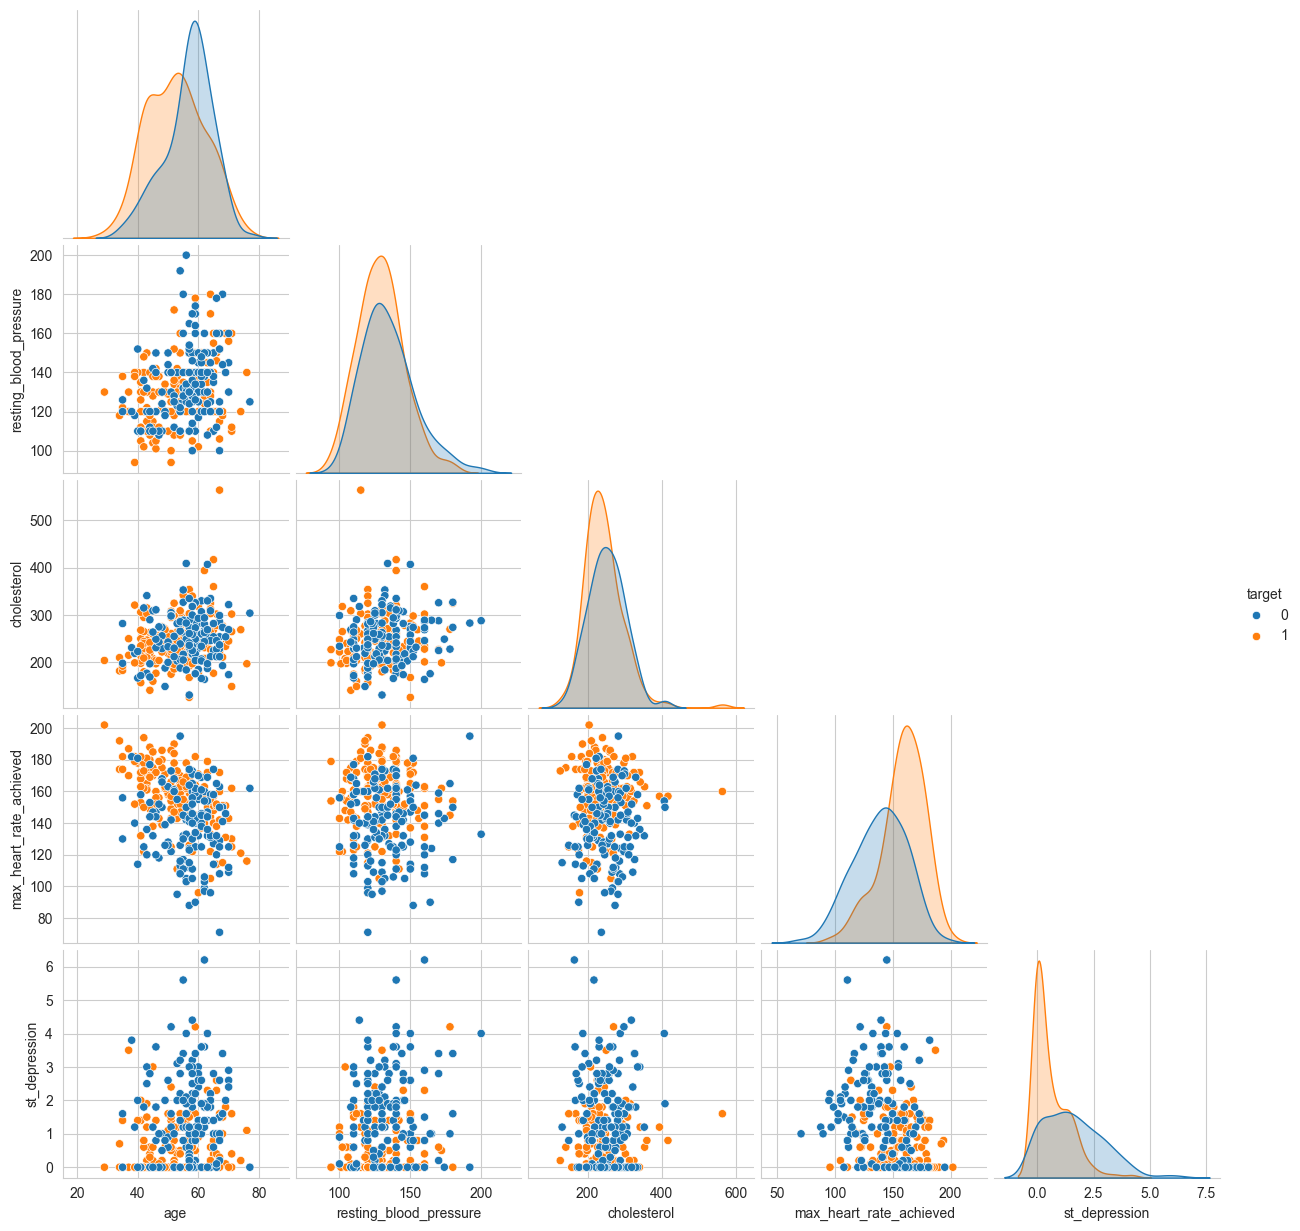

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_features = [
    'age',
    'resting_blood_pressure',
    'cholesterol',
    'max_heart_rate_achieved',
    'st_depression'
]

sns.pairplot(
    data[numerical_features + ['target']],
    hue='target',
    corner=True
)

plt.show()

In [22]:
#Observation
#Except maximum_heart_rate_achieved, the others are positively and linearly related with age (albeit a weaker relation with st_depression).
# Younger patients with higher maximum_heart_rate_achieved are more likely to have a heart condition.
# Lower st_depression regardless of age is also likely an indication of a heart disease.

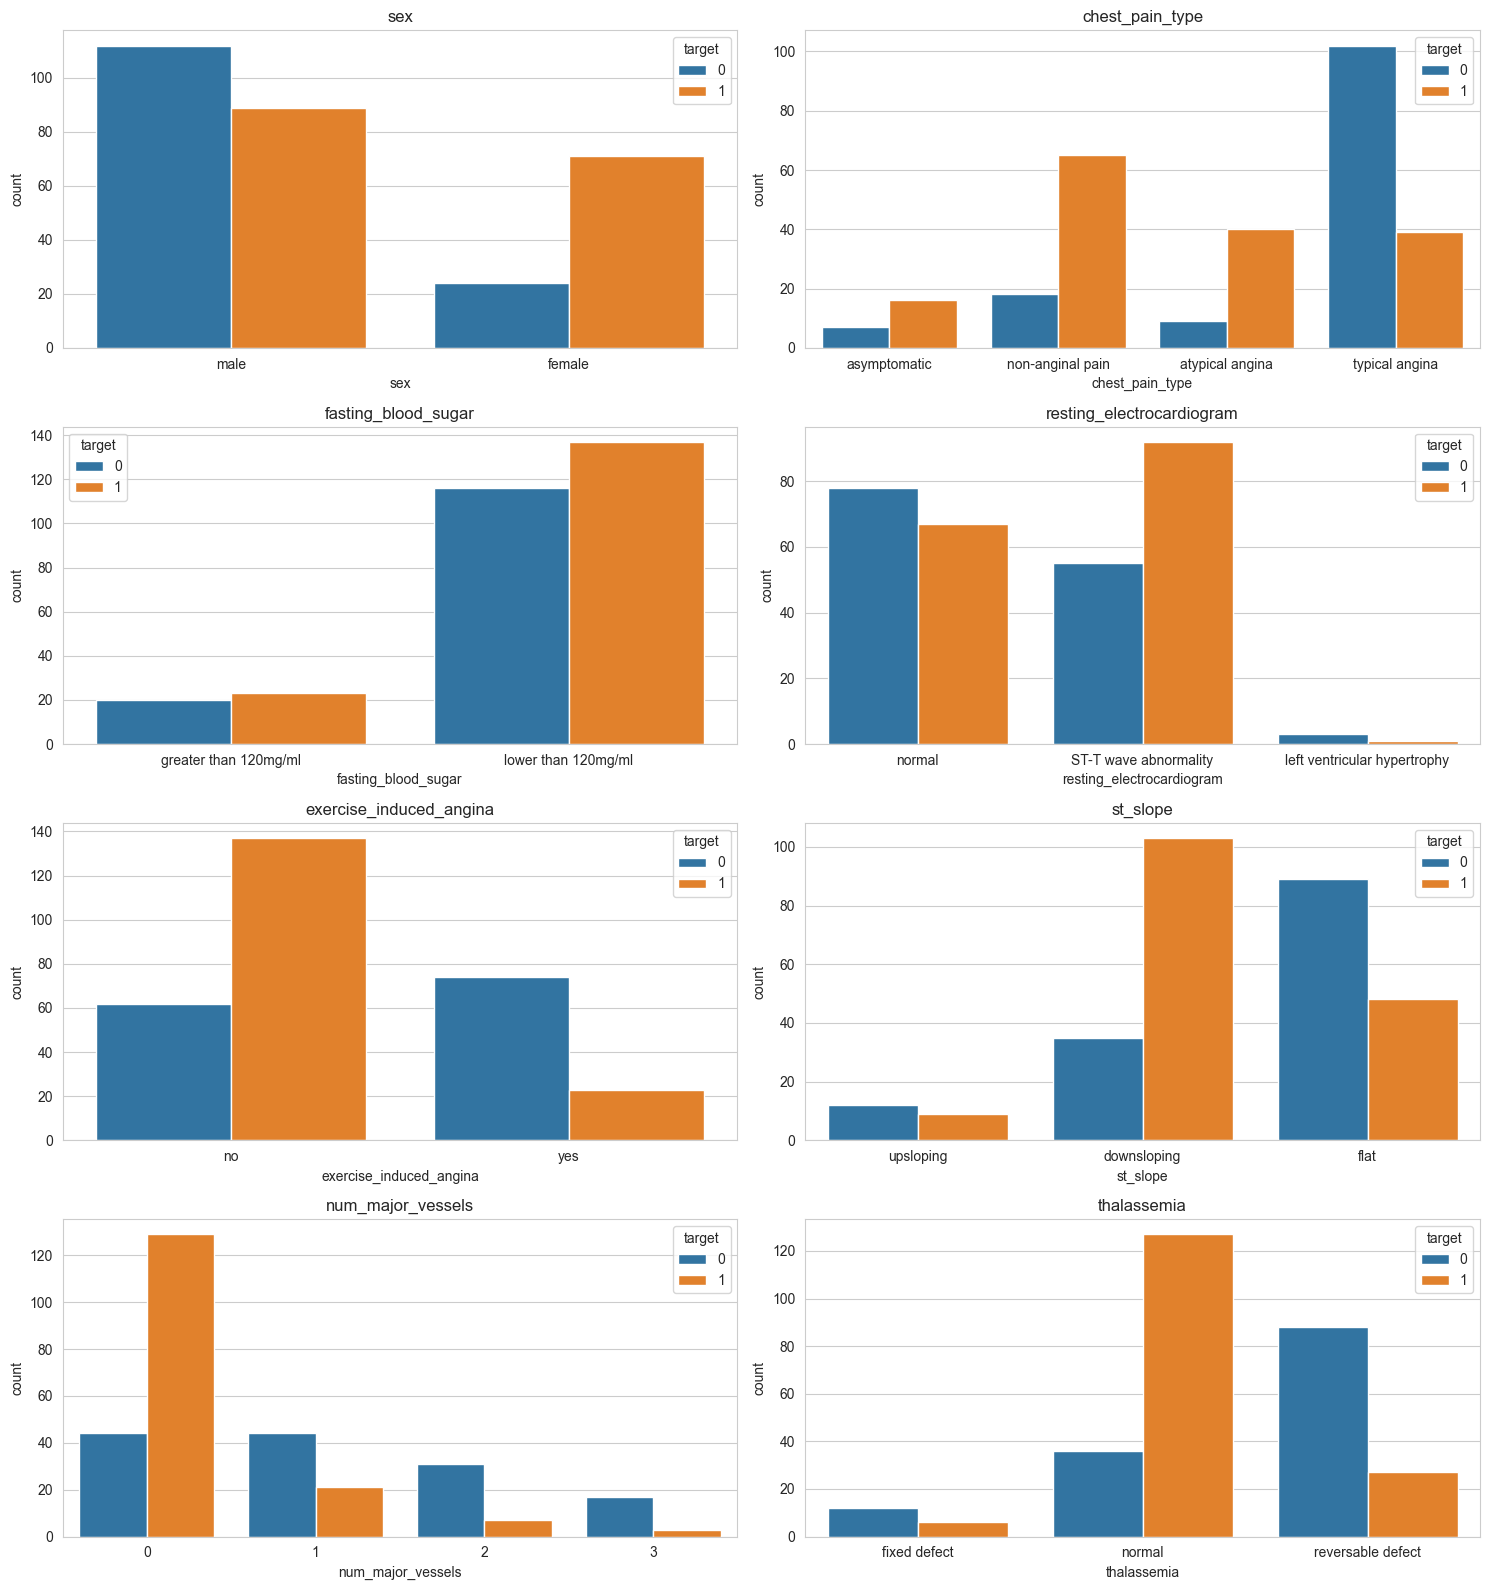

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = [
    'sex',
    'chest_pain_type',
    'fasting_blood_sugar',
    'resting_electrocardiogram',
    'exercise_induced_angina',
    'st_slope',
    'num_major_vessels',
    'thalassemia'
]

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(
        data=data,
        x=feature,
        hue='target',
        ax=axes[i]
    )
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

In [24]:
# Observation:-
# Chest Pain:
# More than 75% of the patients experience either typical angina or non-angina chest pain.
# Patients who experienced atypical angina or non-angina chest pain are more likely to have a heart disease.
# Resting Electrocardiogram:
# Patients with Left ventricular hypertrophy are the fewest (~1.4%). The rest is almost a 50-50 split between patients with ST-T abnormality and those with normal REC tests.
# ST-T abnormality seem to have a better correlation with the target, i.e the majority of patients with this kind of REC test ended up with a heart disease.
# ST-Slope:
# Most patients have a downsloping or flat ST-Slope of their REC test.
# downsloping ST-Slopes are a strong indication that a patient might have a heart disease.
# Thalassemia:
# Most patients have a normal or reversable defect
# Patients who have thalassemia defects (reversable + fixed) are less likely to have a heart disease. Whereas, those with normal thalassemia are more likely to have a heart condition. Sounds not intuitive.
# Fasting blood sugar
# Patients with lower (less than 120mg/ml) fasting blood sugar are the majority in our dataset consisting of ~85% of the sample.
# Having lower resting blood sugar tends to increase the chances (~54%) of a heart disease.
# Exercise Induced Angina
# Two-third of the patients showed no exercise induced angina.
# 76% of the patients with exercise induced angina had no heart conditions. Whereas ~69% of the patients who did not experience exercise induced angina were diagnosed with heart condition.
# Sex
# More patients in the sample data are male.
# Females seem to suffer from heart condition more than males.


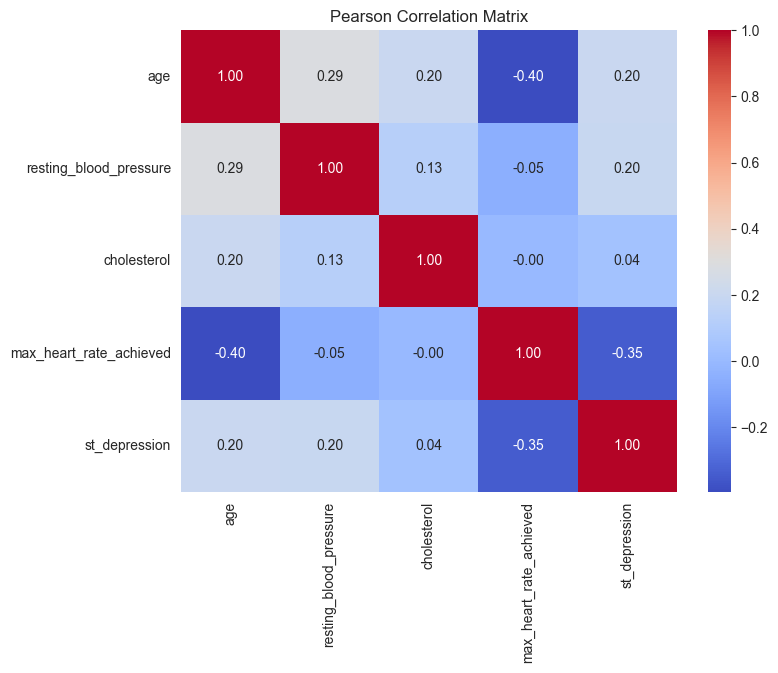

In [25]:
#Pearson Correlation (Numerical vs Numerical)
import pandas as pd

numerical_features = [
    'age',
    'resting_blood_pressure',
    'cholesterol',
    'max_heart_rate_achieved',
    'st_depression'
]

pearson_corr = data[numerical_features].corr(method='pearson')

# print(pearson_corr)
plt.figure(figsize=(8,6))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Pearson Correlation Matrix")
plt.show()

In [26]:
# Point-Biserial Correlation (Feature vs Target)
from scipy.stats import pointbiserialr

numerical_features = [
    'age',
    'resting_blood_pressure',
    'cholesterol',
    'max_heart_rate_achieved',
    'st_depression'
]

for feature in numerical_features:
    
    corr, p_value = pointbiserialr(
        data['target'],
        data[feature]
    )
    
    print(f"{feature}:")
    print(f"Correlation = {corr:.3f}")
    print(f"P-value = {p_value:.5f}")
    print()

age:
Correlation = -0.225
P-value = 0.00009

resting_blood_pressure:
Correlation = -0.149
P-value = 0.01030

cholesterol:
Correlation = -0.077
P-value = 0.18911

max_heart_rate_achieved:
Correlation = 0.427
P-value = 0.00000

st_depression:
Correlation = -0.429
P-value = 0.00000



In [27]:
#Cramér's V (Categorical vs Target)
import pandas as pd
import scipy.stats as stats
import numpy as np

def cramers_v(x, y):
    
    contingency = pd.crosstab(x, y)

    chi2 = stats.chi2_contingency(contingency)[0]

    n = contingency.sum().sum()

    phi2 = chi2 / n

    r, k = contingency.shape

    return np.sqrt(phi2 / min(k - 1, r - 1))
categorical_features = [
    'sex',
    'chest_pain_type',
    'fasting_blood_sugar',
    'resting_electrocardiogram',
    'exercise_induced_angina',
    'st_slope',
    'num_major_vessels',
    'thalassemia'
]

for feature in categorical_features:
    
    v = cramers_v(
        data[feature],
        data['target']
    )

    print(f"{feature}: {v:.3f}")

sex: 0.278
chest_pain_type: 0.508
fasting_blood_sugar: 0.000
resting_electrocardiogram: 0.177
exercise_induced_angina: 0.418
st_slope: 0.388
num_major_vessels: 0.498
thalassemia: 0.532


In [28]:
# EDA summary:-
# Data size: 303 rows and 14 columns (13 independent + one target variable) > later reduced to 296 after removing faulty data points!
# Data has no missing values
# Features (columns) data type:
# Six features are numerical
# The rest (seven features) are categorical variables
# Target variable is fairly balanced, 54% no-disease to 46% has-disease
# Correlations:
# Correlation between features is weak at best
# From the numerical features num_major_vessels, max_heart_rate_achieved and st_depression are reasonabily fairly correlated with the target variable at -0.47, 0.43 and -0.43 correlation coefficient respectively.
# From the categorical features chest_pain_type, num_major_vessels, thalassemia, and exercise_induced_angina are better correlated with the target variable, thalassemia being the highest at 0.52.
# Cholestrol (to my surprize, but what do I know?) has less correlation with heart desease.
# Takeaway: features that have higher predictive power could be, chest_pain_type, num_major_vessels, thalassemia, exercise_induced_angina max_heart_rate_achieved and st_depression. We will see which features will appear as imporatnt by the classification models.

In [29]:
import pandas as pd

# Convert categorical columns into numerical columns
data_encoded = pd.get_dummies(
    data,
    columns=[
        'sex',
        'chest_pain_type',
        'fasting_blood_sugar',
        'resting_electrocardiogram',
        'exercise_induced_angina',
        'st_slope',
        'thalassemia'
    ],
    drop_first=True
)

print(data_encoded.shape)
data_encoded.head()

(296, 19)


,age,resting_blood_pressure,cholesterol,max_heart_rate_achieved,st_depression,num_major_vessels,target,sex_male,chest_pain_type_atypical angina,chest_pain_type_non-anginal pain,chest_pain_type_typical angina,fasting_blood_sugar_lower than 120mg/ml,resting_electrocardiogram_left ventricular hypertrophy,resting_electrocardiogram_normal,exercise_induced_angina_yes,st_slope_flat,st_slope_upsloping,thalassemia_normal,thalassemia_reversable defect
0,63,145,233,150,2.3,0,1,True,False,False,False,False,False,True,False,False,True,False,False
1,37,130,250,187,3.5,0,1,True,False,True,False,True,False,False,False,False,True,True,False
2,41,130,204,172,1.4,0,1,False,True,False,False,True,False,True,False,False,False,True,False
3,56,120,236,178,0.8,0,1,True,True,False,False,True,False,False,False,False,False,True,False
4,57,120,354,163,0.6,0,1,False,False,False,True,True,False,False,True,False,False,True,False


In [30]:
print(data.dtypes)


age                            int64
sex                           object
chest_pain_type               object
resting_blood_pressure         int64
cholesterol                    int64
fasting_blood_sugar           object
resting_electrocardiogram     object
max_heart_rate_achieved        int64
exercise_induced_angina       object
st_depression                float64
st_slope                      object
num_major_vessels              int64
thalassemia                   object
target                         int64
dtype: object


In [31]:
X = data_encoded.drop('target', axis=1)
y = data_encoded['target']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size = 0.2,random_state = 42 ,stratify = y
)

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [34]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

In [35]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8166666666666667


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(y_true, y_pred):

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

In [37]:
evaluate_model(y_test, y_pred)

Accuracy : 0.8166666666666667
Precision: 0.8181818181818182
Recall   : 0.84375
F1 Score : 0.8307692307692308

Confusion Matrix
[[22  6]
 [ 5 27]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.84      0.83        32

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.82        60
weighted avg       0.82      0.82      0.82        60



In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [39]:
evaluate_model(y_test, y_pred_rf)

Accuracy : 0.8
Precision: 0.8125
Recall   : 0.8125
F1 Score : 0.8125

Confusion Matrix
[[22  6]
 [ 6 26]]

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.81      0.81      0.81        32

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



In [40]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [41]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
evaluate_model(y_test, y_pred_xgb)

Accuracy : 0.8166666666666667
Precision: 0.8181818181818182
Recall   : 0.84375
F1 Score : 0.8307692307692308

Confusion Matrix
[[22  6]
 [ 5 27]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.84      0.83        32

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.82        60
weighted avg       0.82      0.82      0.82        60



In [43]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Fold Accuracies:", scores)
print("Mean Accuracy:", scores.mean())

C:\Users\praya\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\praya\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_mo

Fold Accuracies: [0.86666667 0.89830508 0.81355932 0.81355932 0.76271186]
Mean Accuracy: 0.8309604519774012


C:\Users\praya\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

evaluate_model(y_test, y_pred_gb)

Accuracy : 0.8
Precision: 0.8125
Recall   : 0.8125
F1 Score : 0.8125

Confusion Matrix
[[22  6]
 [ 6 26]]

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.81      0.81      0.81        32

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



In [45]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                           Feature  Importance
3          max_heart_rate_achieved    0.128155
5                num_major_vessels    0.126124
4                    st_depression    0.110851
16              thalassemia_normal    0.107870
17   thalassemia_reversable defect    0.082749
0                              age    0.079604
2                      cholesterol    0.068829
9   chest_pain_type_typical angina    0.067526
1           resting_blood_pressure    0.062928
13     exercise_induced_angina_yes    0.045004


In [46]:
#The ROC curve shows how well the model separates patients with and without heart disease across different classification thresholds.
from sklearn.metrics import roc_auc_score

y_prob = lr.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))

ROC-AUC Score: 0.8951


In [47]:
import joblib

joblib.dump(lr, 'heart_disease_model.pkl')
joblib.dump(scaler, 'heart_scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [48]:
print(X.columns.tolist())

['age', 'resting_blood_pressure', 'cholesterol', 'max_heart_rate_achieved', 'st_depression', 'num_major_vessels', 'sex_male', 'chest_pain_type_atypical angina', 'chest_pain_type_non-anginal pain', 'chest_pain_type_typical angina', 'fasting_blood_sugar_lower than 120mg/ml', 'resting_electrocardiogram_left ventricular hypertrophy', 'resting_electrocardiogram_normal', 'exercise_induced_angina_yes', 'st_slope_flat', 'st_slope_upsloping', 'thalassemia_normal', 'thalassemia_reversable defect']


In [50]:
import joblib
import numpy as np

# Load saved model and scaler
model = joblib.load("heart_disease_model.pkl")
scaler = joblib.load("heart_scaler.pkl")

# Patient data (18 features in exact order)

patient = [
    55,     # age
    130,    # resting_blood_pressure
    250,    # cholesterol
    150,    # max_heart_rate_achieved
    1.2,    # st_depression
    0,      # num_major_vessels

    1,      # sex_male

    0,      # chest_pain_type_atypical angina
    1,      # chest_pain_type_non-anginal pain
    0,      # chest_pain_type_typical angina

    1,      # fasting_blood_sugar_lower than 120mg/ml

    0,      # resting_electrocardiogram_left ventricular hypertrophy
    1,      # resting_electrocardiogram_normal

    0,      # exercise_induced_angina_yes

    1,      # st_slope_flat
    0,      # st_slope_upsloping

    1,      # thalassemia_normal
    0       # thalassemia_reversable defect
]

# Convert to numpy array
patient = np.array(patient).reshape(1, -1)

# Scale input
patient_scaled = scaler.transform(patient)

# Prediction
prediction = model.predict(patient_scaled)[0]

# Probability of heart disease
probability = model.predict_proba(patient_scaled)[0][1] * 100

print("=" * 50)

if probability >= 80:
    print(f"🔴 High Risk ({probability:.2f}%)")
elif probability >= 50:
    print(f"🟠 Moderate Risk ({probability:.2f}%)")
else:
    print(f"🟢 Low Risk ({probability:.2f}%)")
print("=" * 50)

🔴 High Risk (85.16%)


C:\Users\praya\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
